In [ ]:
import os; os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import json, re, copy, itertools, collections
from types import SimpleNamespace
import numpy as np, torch, matplotlib.pyplot as plt
from dotenv import load_dotenv; load_dotenv(".env")         # HF_TOKEN (Llama is gated); OPENAI_API_KEY only to re-run the agent
from mcp_live import workspace, catalog, tasks as task_lib, agent

STRICT = True       # reward also requires that every attached server was used; False: the checker alone
FREE_TEXT = True       # the model writes the whole answer; False: only the four digits are sampled (constrained decoding)

SLOTS, BUDGET = catalog.SLOTS, catalog.BUDGET                    # 4 slots x 3 servers; the client attaches at most 2
CONFIGS = list(itertools.product(range(4), repeat=4))            # one digit per slot, 0 = none: 256 configurations
OVER_CAP = np.array([sum(d > 0 for d in c) > BUDGET for c in CONFIGS])
servers_of = lambda c: [SLOTS[j][1][d - 1] for j, d in enumerate(c) if d > 0]

TASKS = {t["id"]: t for t in task_lib.make_tasks(workspace.build_template(), workspace.start_intranet())}
SERVERS = json.load(open("mcp_live/catalog.json"))              # what each server announces about itself over MCP
for slot, names in SLOTS:
    print(f"{slot:<10}", " | ".join(names))
print()
for t in TASKS.values():
    print(f"{t['id']:<10} {t['spec'][:110]}")

files      filesystem | grep | git
knowledge  sqlite | fetch | notes
execution  python | pytest | lint
delivery   write_file | mail | ticket

port       What TCP port does the service listen on according to config.ini in the workspace? Reply with the port number.
shipped    How many orders in the project database data.db have status 'shipped'? Write just that number into a new file 
retries    The vendor SDK docs page http://127.0.0.1:8765/docs/retries.html states how many times a failed request is ret
digest     Compute the SHA-256 hex digest of the exact contents of secret.txt in the workspace (the file has no trailing 
passing    Run the project's test suite and reply with the number of tests that pass.
author     Find the author of the most recent git commit that changed src/mod_17.py and e-mail that person's full name to
ratelimit  The intranet page http://127.0.0.1:8765/docs/limits.html states the vendor's per-minute request limit. Open a 
defines    Which file in the workspace d

In [2]:
RUN_AGENT = False
EPISODES_FILE = "_live_rewards_gpt-4.1-mini_transcripts.jsonl"
if RUN_AGENT:
    EPISODES_FILE = "my_episodes.jsonl"
    await agent.fill_cache(list(TASKS.values()), CONFIGS, "my_rewards.json", repeats=2, transcripts_path=EPISODES_FILE)

episodes = [json.loads(line) for line in open(EPISODES_FILE)]

def reward(ep):                                                  # one episode -> 0 or 1
    used = {call.split("__")[0] for call in ep["calls"]}         # the servers the agent actually called
    return float(ep["f"] and (not STRICT or set(ep["servers"]) <= used))

runs = collections.defaultdict(list)
for ep in episodes:
    runs[ep["task"], tuple(ep["config"])].append(reward(ep))
REWARD = {t: np.array([np.mean(runs.get((t, c), [0.0])) for c in CONFIGS]) for t in TASKS}   # over the cap: never run, 0

for t, r in REWARD.items():
    wins = [CONFIGS[i] for i in np.flatnonzero(r > 0)]
    print(f"{t:<10} {len(wins):>2} of 256 succeed: " + ", ".join("+".join(servers_of(c)) for c in wins[:5]) + (" ..." if len(wins) > 5 else ""))

port        2 of 256 succeed: filesystem, grep
shipped     2 of 256 succeed: pytest+write_file, sqlite+write_file
retries     1 of 256 succeed: fetch
digest      1 of 256 succeed: filesystem+python
passing     1 of 256 succeed: pytest
author      1 of 256 succeed: git+mail
ratelimit   1 of 256 succeed: fetch+ticket
defines     3 of 256 succeed: filesystem, grep, git
lint        3 of 256 succeed: lint, filesystem, filesystem+pytest
oncall      1 of 256 succeed: notes+mail


In [3]:
ep = next(e for e in episodes if e["task"] == "port" and e["servers"] == ["filesystem", "mail"])
for line in ep["transcript"]:
    print(line.replace("\n", " ")[:130])
print(f"\nchecker: {ep['f']}   servers given: {ep['servers']}   reward: {reward(ep)}")

tool filesystem__list_files({}) -> README.md config.ini conftest.py data.db secret.txt utils.py src/mod_01.py src/mod_02.py src/mo
tool filesystem__read_file({"path": "config.ini"}) -> [server] host = 0.0.0.0 port = 8443 workers = 4  [retry] attempts = 3 backof
assistant: The service listens on TCP port 8443 according to config.ini.  ANSWER: 8443

checker: 1.0   servers given: ['filesystem', 'mail']   reward: 0.0


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model

MODEL = "meta-llama/Llama-3.2-3B-Instruct"
tok = AutoTokenizer.from_pretrained(MODEL, clean_up_tokenization_spaces=False)
base = AutoModelForCausalLM.from_pretrained(MODEL, dtype=torch.float32).cuda().requires_grad_(False)
torch.manual_seed(0)                                             # lora_A's random draw sets the gradient geometry: fix it
model = get_peft_model(base, LoraConfig(r=8, lora_alpha=16, target_modules=["down_proj"], layers_to_transform=[27])).eval()
params = [p for n, p in model.named_parameters() if "lora" in n]
start_params = [p.detach().clone() for p in params]
def reset():
    for p, p0 in zip(params, start_params): p.data.copy_(p0)

SYSTEM = ("You configure the MCP servers of an autonomous agent that will carry out a small task in a project workspace. "
          "There are four capability slots; each offers three servers, and 0 leaves the slot empty. The client attaches at most "
          f"{BUDGET} servers in total: a configuration with more than {BUDGET} is rejected and the task fails. Attach exactly the "
          "servers the task needs: the agent can only use what you attach, and a missing or wrong server makes the task "
          "impossible. Answer with one line per slot, in the order given, in exactly this form:\n"
          + "\n".join(f"{slot}: <0|1|2|3>" for slot, _ in SLOTS) + "\nEND")

def legend(slot, names):
    return f"{slot}: 0 = no server; " + "; ".join(
        f"{i + 1} = {n} ({SERVERS[n]['instructions'].rstrip('.')}; tools: {', '.join(t['name'] for t in SERVERS[n]['tools'])})"
        for i, n in enumerate(names))

PREFILL = "files: "
enc = lambda s: tok.encode(s, add_special_tokens=False)
def prompt_ids(task_id):
    user = f"Task: {TASKS[task_id]['spec']}\nSlots:\n" + "\n".join(legend(s, n) for s, n in SLOTS)
    chat = tok.apply_chat_template([{"role": "system", "content": SYSTEM}, {"role": "user", "content": user}], tokenize=False, add_generation_prompt=True)
    return enc(chat + PREFILL)

DIGITS = [enc(str(d))[0] for d in range(4)]
TEMPLATE = []
for j, (slot, _) in enumerate(SLOTS):
    TEMPLATE += (enc(f"\n{slot}: ") if j else []) + [None]
fill = lambda template, digits: [DIGITS[digits[template[:i].count(None)]] if t is None else t for i, t in enumerate(template)]
assert enc(PREFILL + "1\nknowledge: 0\nexecution: 2\ndelivery: 3") == enc(PREFILL) + fill(TEMPLATE, (1, 0, 2, 3))
print("answer template:", PREFILL + "".join("<d>" if t is None else tok.decode([t]) for t in TEMPLATE).replace("\n", "\\n"))

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

answer template: files: <d>\nknowledge: <d>\nexecution: <d>\ndelivery: <d>


What the untrained model writes on its own:

In [5]:
ANSWER = re.compile(r"files: ([0-3])\nknowledge: ([0-3])\nexecution: ([0-3])\ndelivery: ([0-3])(?!\d)")
def parse(text):
    m = ANSWER.match(text); return CONFIGS.index(tuple(map(int, m.groups()))) if m else -1

job = "lint"
ids = torch.tensor([prompt_ids(job)] * 6, device="cuda")
torch.manual_seed(0)
out = model.generate(ids, attention_mask=torch.ones_like(ids), do_sample=True, temperature=1.0, top_p=1.0, top_k=0,     # the full distribution (Llama's defaults truncate it)
                     max_new_tokens=24, pad_token_id=tok.eos_token_id)
for row in out:
    text = PREFILL + tok.decode(row[ids.shape[1]:], skip_special_tokens=True); c = parse(text)
    got = ("+".join(servers_of(CONFIGS[c])) or "nothing") if c >= 0 else "unparseable"
    print(f"{text[:70]!r:<74} -> {got:<22} reward {REWARD[job][c] if c >= 0 else 0.0}")

'files: 1\nknowledge: 0\nexecution: 0\ndelivery: 0'                        -> filesystem             reward 0.5
'files: 1\nknowledge: 0\nexecution: 0\ndelivery: 0\nEND\n\n(Note: pyflakes' -> filesystem             reward 0.5
'files: 1\nknowledge: 0\nexecution: 0\ndelivery: 0\nEND'                   -> filesystem             reward 0.5
'files: 1\nknowledge: 0\nexecution: 3\ndelivery: 0'                        -> filesystem+lint        reward 0.0
'files: 1\nknowledge: 2\nexecution: 3\ndelivery: 0'                        -> filesystem+fetch+lint  reward 0.0
'files: 1\nknowledge: 3\nexecution: 3\ndelivery: 0'                        -> filesystem+notes+lint  reward 0.0


In [ ]:
lm, last = model.base_model.model, model.base_model.model.model.layers[-1]
saved = {}
last.post_attention_layernorm.register_forward_pre_hook(lambda m, a: saved.update(r=a[0]))    # the residual stream
last.mlp.down_proj.register_forward_pre_hook(lambda m, a: saved.update(x=a[0]))               # the LoRA's input

def build_tree(task_id, chunk=64):
    prompt = prompt_ids(task_id)
    steps = [k for k, t in enumerate(TEMPLATE) if t is None or FREE_TEXT]                   # positions the model is scored on
    nodes = [(k, d) for k in steps for d in itertools.product(range(4), repeat=TEMPLATE[:k].count(None))]
    allowed = [DIGITS if TEMPLATE[k] is None else [TEMPLATE[k]] for k, _ in nodes]         # plus one branch: anything else
    size = [len(a) + 1 for a in allowed]; first = np.cumsum([0] + size[:-1]); E = sum(size)

    leaves = []                                                  # (entries taken on the way, configuration index or -1)
    def walk(i, digits, path):
        n = nodes.index((steps[i], digits)); A = len(allowed[n])
        leaves.append((path + [first[n] + A], -1))                                          # anything else
        for j in range(A):
            nxt = digits + (j,) if A == 4 else digits
            if i + 1 < len(steps): walk(i + 1, nxt, path + [first[n] + j])
            else: leaves.append((path + [first[n] + j], CONFIGS.index(nxt)))
    walk(0, (), [])
    node_first, node_size = np.repeat(first, size), np.repeat(size, size)
    taken, passed = np.zeros((len(leaves), E)), np.zeros((len(leaves), E))                 # passed: every branch of every node on the way
    for y, (path, _) in enumerate(leaves):
        taken[y, path] = 1
        for e in path: passed[y, node_first[e]:node_first[e] + node_size[e]] = 1

    # One forward: the 64 answers that spell out every choice of the first three digits contain every prefix in the tree.
    lines = list(itertools.product(range(4), repeat=TEMPLATE.count(None) - 1))
    with torch.no_grad():
        kv = lm.model(input_ids=torch.tensor([prompt[:-1]], device="cuda")).past_key_values; kv.batch_repeat_interleave(len(lines))
        lm.model(input_ids=torch.tensor([prompt[-1:] + fill(TEMPLATE[:-1], d) for d in lines], device="cuda"), past_key_values=kv)
    X, R = saved["x"], saved["r"]                                                          # (64, 16, .): position k predicts TEMPLATE[k]
    at = [(lines.index(d + (0,) * (len(lines[0]) - len(d))), k) for k, d in nodes]

    P = torch.zeros(E, dtype=torch.float64, device="cuda"); Z = torch.zeros(E, sum(p.numel() for p in params), device="cuda")
    W = lm.lm_head.weight
    for A1 in sorted(set(size)):
        group = [n for n in range(len(nodes)) if size[n] == A1]
        for c in range(0, len(group), chunk):
            g = group[c:c + chunk]; B = len(g); s, k = map(list, zip(*[at[n] for n in g]))
            h = lm.model.norm(R[s, k][:, None] + last.mlp.down_proj(X[s, k][:, None]))[:, 0]   # (B, d), carries the LoRA gradient
            with torch.no_grad():
                logp = torch.log_softmax(lm.lm_head(h), -1); p = logp.exp()
                ok = torch.tensor([allowed[n] for n in g], device="cuda")
                rest = torch.ones_like(p).scatter_(1, ok, 0.0)                                # the tokens that break the answer
                lp = torch.cat([logp.gather(1, ok), (logp + rest.log()).logsumexp(-1, keepdim=True)], 1)
                q = p * rest / (p * rest).sum(-1, keepdim=True).clamp_min(1e-30)
                dlp_dh = torch.cat([W[ok], (q @ W)[:, None]], 1) - (p @ W)[:, None]          # d log p(branch) / d h, (B, A1, d)
            onehot = torch.zeros(B * A1, B, h.shape[1], device="cuda")
            onehot[torch.arange(B * A1), torch.arange(B).repeat_interleave(A1)] = dlp_dh.reshape(B * A1, -1)
            grads = torch.autograd.grad(h, params, onehot, is_grads_batched=True)             # one score per branch
            rows = torch.tensor([first[n] + a for n in g for a in range(A1)], device="cuda")
            pr = lp.double().exp(); P[rows] = (pr / pr.sum(1, keepdim=True)).flatten()
            Z[rows] = torch.cat([x.reshape(B * A1, -1) for x in grads], 1)

    T = lambda a: torch.tensor(a, dtype=torch.float64, device="cuda")
    tree = SimpleNamespace(P=P, Z=Z, K=(Z @ Z.T).double(), taken=T(taken), passed=T(passed), conf=np.array([c for _, c in leaves]),
                           node=torch.tensor(np.repeat(np.arange(len(nodes)), size), device="cuda"))     # the node of every entry
    tree.pb = torch.exp(tree.taken @ torch.log(P.clamp_min(1e-300)))                         # probability of every leaf
    return tree

def leaf_rewards(tree, table):                                   # a table over the 256 configurations -> one reward per leaf
    return torch.tensor(np.where(tree.conf >= 0, table[np.maximum(tree.conf, 0)], 0.0), device="cuda")

tree = build_tree(job); f = leaf_rewards(tree, REWARD[job])
print(f"{job}: {tree.P.numel()} (prefix, token) entries, {len(tree.conf)} leaves;  P(parseable) = {tree.pb[tree.conf >= 0].sum():.3f},  P(success) = {tree.pb @ f:.4f}")

lint: 1097 (prefix, token) entries, 677 leaves;  P(parseable) = 0.939,  P(success) = 0.1568


In [7]:
def weights(tree, c, f):             # ĝ(y) = weights[y] @ Z, for every leaf y at once
    return tree.taken * (f[:, None] - c) + tree.passed * (tree.P * c)

def noise(tree, c, f):               # exact Var[ĝ] under the current policy
    A = weights(tree, c, f); D = A - tree.pb @ A
    return float(tree.pb @ ((D @ tree.K) * D).sum(1))

def Q_table(tree, f):                # E[f | the answer reached this prefix and wrote this token]
    n = tree.pb @ tree.taken
    return torch.where(n > 0, (tree.pb * f) @ tree.taken / n.clamp_min(1e-300), 0.0)

def Delta_table(tree, f, Q):         # argmin over Δ of Var[ĝ] with c = Q + Δ
    A = weights(tree, Q, f); R = A - tree.pb @ A
    dA = tree.passed * tree.P - tree.taken                      # weights(c + Δ) = weights(c) + dA * Δ
    M = tree.K * (dA.T @ (tree.pb[:, None] * dA)); b = -(((R @ tree.K) * dA).T @ tree.pb)
    return torch.linalg.pinv(M, hermitian=True, rtol=1e-8) @ b

class Seen:
    # the agent episodes so far: f-hat per configuration, and the average reward for REINFORCE
    def __init__(self):
        self.n, self.sum, self.all = np.zeros(len(CONFIGS)), np.zeros(len(CONFIGS)), []
    def add(self, conf, f):
        self.all.append(f)
        if conf >= 0: self.n[conf] += 1; self.sum[conf] += f
    def f_hat(self, prior=1.0):
        tried = (self.n > 0) & ~OVER_CAP
        m = (self.sum[tried] / self.n[tried]).mean() if tried.any() else 0.0
        return np.where(OVER_CAP, 0.0, (self.sum + prior * m) / (self.n + prior))   # over the cap: the client's rule, a known 0

def control_variate(method, tree, seen, f_true):
    if method == "REINFORCE":
        return torch.full_like(tree.P, np.mean(seen.all) if seen.all else 0.0)
    f = f_true if "exact" in method else leaf_rewards(tree, seen.f_hat())     # "(exact)": the true reward, a ceiling
    Q = Q_table(tree, f)
    return Q + Delta_table(tree, f, Q) if "Δ" in method else Q

def sample(tree, n, rng):
    return rng.choice(len(tree.conf), size=n, p=(tree.pb / tree.pb.sum()).cpu().numpy())

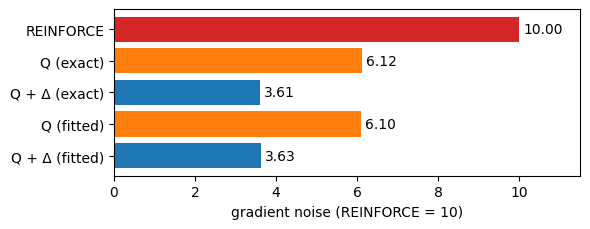

Δ removes 41% of the noise left by exact Q, and 40% of the noise left by fitted Q.


In [ ]:
M = 2000
rng = np.random.default_rng(0); total = collections.Counter()
for t in TASKS:
    tree = build_tree(t); f = leaf_rewards(tree, REWARD[t])
    seen = Seen()
    for y in sample(tree, M, rng): 
        seen.add(tree.conf[y], float(f[y]))
    exact_Q, fit_Q = Q_table(tree, f), Q_table(tree, leaf_rewards(tree, seen.f_hat()))
    total["REINFORCE"] += noise(tree, torch.full_like(tree.P, float(tree.pb @ f)), f)
    total["Q (exact)"] += noise(tree, exact_Q, f)
    total["Q + Δ (exact)"] += noise(tree, exact_Q + Delta_table(tree, f, exact_Q), f)
    total["Q (fitted)"] += noise(tree, fit_Q, f)
    total["Q + Δ (fitted)"] += noise(tree, fit_Q + Delta_table(tree, leaf_rewards(tree, seen.f_hat()), fit_Q), f)
    del tree

share = {k: 10 * v / total["REINFORCE"] for k, v in total.items()}
names = list(share)[::-1]
plt.figure(figsize=(6, 2.4))
plt.barh(names, [share[k] for k in names], color=["C0" if "Δ" in k else "C1" if k.startswith("Q") else "C3" for k in names])
for i, k in enumerate(names): plt.text(share[k] + 0.1, i, f"{share[k]:.2f}", va="center")
plt.xlabel("gradient noise (REINFORCE = 10)"); plt.xlim(0, 11.5); plt.tight_layout(); plt.show()
print(f"Δ removes {1 - share['Q + Δ (exact)'] / share['Q (exact)']:.0%} of the noise left by exact Q, "
      f"and {1 - share['Q + Δ (fitted)'] / share['Q (fitted)']:.0%} of the noise left by fitted Q.")

In [9]:
import sys; sys.path.insert(0, ".."); import torch.nn.functional as F
from baselines import group_weights, relax_weights, Surrogate
GROUP = 4                                                        # episodes per job per step for the group baselines
BASELINES = {"RLOO": GROUP, "GRPO": GROUP, "OTB": GROUP, "RELAX": 1}
SCORED = [k for k, t in enumerate(TEMPLATE) if t is None or FREE_TEXT]     # the positions the tree scores, as in build_tree
DIGIT_POS = [i for i, k in enumerate(SCORED) if TEMPLATE[k] is None]      # which of them write a digit

def decisions(tree, ys):                                         # each leaf as its sequence of decisions: one entry per position, -1 after an early end
    return torch.nn.utils.rnn.pad_sequence([tree.taken[y].nonzero().squeeze(1) for y in ys], batch_first=True, padding_value=-1)

def nodes(tree, ys, T=len(SCORED), A=5):                       # the nodes each leaf went through: their entries (K, T, A), -1 = none; the branch taken (K, T)
    ent = torch.full((len(ys), T, A), -1, device="cuda"); b = torch.zeros(len(ys), T, dtype=torch.long, device="cuda")
    for i, y in enumerate(ys):
        es = tree.passed[y].nonzero().squeeze(1)                 # every branch of every node on the way, in position order
        for t, n in enumerate(tree.node[es].unique()):
            g = es[tree.node[es] == n]; ent[i, t, :len(g)] = g; b[i, t] = (tree.taken[y][g] > 0).nonzero()
    return ent, b

def state(b, T=len(SCORED)):                                   # what RELAX's surrogate knows at each position: the position, and the digits already written
    t = torch.arange(T, device="cuda")
    digits = [F.one_hot(torch.where(t > k, b[:, k, None], 4), 5) for k in DIGIT_POS[:-1]]     # 4 = not written yet
    return torch.cat([F.one_hot(t, T).expand(len(b), T, T), *digits], -1).float()

def baseline_weights(method, tree, ys, f, surrogates, task, gen):     # w with ĝ = w @ Z, like weights(tree, c, f)[ys].mean(0)
    if method == "RELAX":
        ent, b = nodes(tree, ys); st = state(b)
        if task not in surrogates: surrogates[task] = Surrogate(st.shape[-1] + 5).cuda()
        c = surrogates[task]
        w = relax_weights(c, torch.log(tree.P.clamp_min(1e-300))[ent.clamp_min(0)].float(), ent, b, f[ys].float(), len(tree.P), st, gen)
        g = w.detach(); c.fit(w, tree.K)
        return g
    pos = decisions(tree, ys)
    return group_weights(method, f[ys], (pos >= 0).double(), pos, tree.K.diagonal())

In [10]:
TRAIN = ["port", "digest", "defines", "lint"]
EPISODES, STEPS, LR = 1, 60, 1e-3                              # episodes per job per step (4 per step in total)

def train(method, seed, episodes=EPISODES, steps=STEPS):
    reset(); rng = np.random.default_rng(seed); gen = torch.Generator("cuda").manual_seed(seed); opt = torch.optim.Adam(params, lr=LR)
    seen = {t: Seen() for t in TRAIN}; surrogates = {}; log = []
    for step in range(steps + 1):
        grad, success, var, var_rf = 0.0, [], 0.0, 0.0
        for t in TRAIN:
            tree = build_tree(t); f = leaf_rewards(tree, REWARD[t])
            success.append(float(tree.pb @ f)); var_rf += noise(tree, torch.full_like(tree.P, float(tree.pb @ f)), f)
            if method in BASELINES: var = np.nan                     # no table, so no exact noise
            else: c = control_variate(method, tree, seen[t], f); var += noise(tree, c, f)
            if step < steps:
                ys = sample(tree, episodes, rng)
                w = baseline_weights(method, tree, ys, f, surrogates, t, gen) if method in BASELINES else weights(tree, c, f)[ys].mean(0)
                grad = grad + (w.float() @ tree.Z) / len(TRAIN)
                for y in ys: seen[t].add(tree.conf[y], float(f[y]))
            del tree
        log.append((step * episodes * len(TRAIN), np.mean(success), var / max(var_rf, 1e-30)))
        if step < steps:
            opt.zero_grad()
            for p, g in zip(params, (-grad).split([p.numel() for p in params])): p.grad = g.view_as(p)
            opt.step()
    return np.array(log)

METHODS = ["REINFORCE", "Q", "Q + Δ", "Q (exact)", "Q + Δ (exact)"]      # "(exact)": the true reward in place of f-hat, a ceiling
SEEDS = [0, 1, 2]              # ~20 min on one H100. Single runs are noisy: compare methods over ~20 seeds (~2.5 h)
logs = {m: np.stack([train(m, s) for s in SEEDS]) for m in METHODS}
for m, K in BASELINES.items():                                 # the same episode budget: K episodes per job per step, STEPS / K steps
    logs[m] = np.stack([train(m, s, episodes=K, steps=STEPS * EPISODES // K) for s in SEEDS])

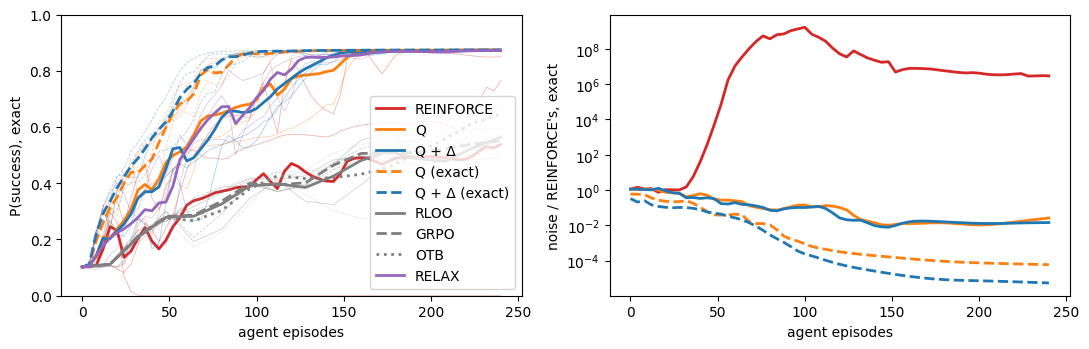

REINFORCE      runs reaching 0.8: 1/3   mean P(success) over the first 100 episodes: 0.262   noise share over the first 10 steps: 1.31
Q              runs reaching 0.8: 3/3   mean P(success) over the first 100 episodes: 0.448   noise share over the first 10 steps: 0.80
Q + Δ          runs reaching 0.8: 3/3   mean P(success) over the first 100 episodes: 0.425   noise share over the first 10 steps: 0.79
Q (exact)      runs reaching 0.8: 3/3   mean P(success) over the first 100 episodes: 0.572   noise share over the first 10 steps: 0.31
Q + Δ (exact)  runs reaching 0.8: 3/3   mean P(success) over the first 100 episodes: 0.596   noise share over the first 10 steps: 0.14
RLOO           runs reaching 0.8: 0/3   mean P(success) over the first 100 episodes: 0.243   noise share over the first 10 steps: nan
GRPO           runs reaching 0.8: 0/3   mean P(success) over the first 100 episodes: 0.247   noise share over the first 10 steps: nan
OTB            runs reaching 0.8: 0/3   mean P(success) o

In [11]:
style = {"REINFORCE": ("C3", "-"), "Q": ("C1", "-"), "Q + Δ": ("C0", "-"), "Q (exact)": ("C1", "--"), "Q + Δ (exact)": ("C0", "--"),
         "RLOO": ("C7", "-"), "GRPO": ("C7", "--"), "OTB": ("C7", ":"), "RELAX": ("C4", "-")}
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for m, L in logs.items():                                      # a log row: (episodes so far, P(success), noise / REINFORCE's)
    col, ls = style.get(m, ("k", ":")); episodes = L[0, :, 0]
    ax[0].plot(episodes, L[:, :, 1].mean(0), color=col, ls=ls, lw=2, label=m)
    for run in L: ax[0].plot(episodes, run[:, 1], color=col, ls=ls, lw=0.6, alpha=0.35)
    if m not in BASELINES: ax[1].plot(episodes, np.exp(np.log(L[:, :, 2]).mean(0)), color=col, ls=ls, lw=2, label=m)
ax[0].set(xlabel="agent episodes", ylabel="P(success), exact", ylim=(0, 1)); ax[0].legend()
ax[1].set(xlabel="agent episodes", ylabel="noise / REINFORCE's, exact", yscale="log")
plt.tight_layout(); plt.show()

for m, L in logs.items():
    first100 = L[0, :, 0] <= 100
    print(f"{m:<14} runs reaching 0.8: {int((L[:, :, 1] >= 0.8).any(1).sum())}/{len(L)}   mean P(success) over the first 100 episodes: "
          f"{L[:, first100, 1].mean():.3f}   noise share over the first 10 steps: {np.exp(np.log(L[:, :10, 2]).mean()):.2f}")